# **Project Name** - Uber Supply-Demand Gap Analysis

##### **Project Type** - EDA (Individual)
##### **Name** - Prayag Gandas

# **Project Summary -**

This project performs an Exploratory Data Analysis (EDA) on Uber ride request data to identify and understand the supply-demand gap — situations where ride requests go unfulfilled either due to cancellations by drivers or unavailability of cars.

The dataset contains 6,745 ride requests recorded between July 11–15, 2016, capturing trips between the city and the airport. Each record includes the pickup point, request and drop timestamps, driver ID, and the final status of the request (Trip Completed, Cancelled, or No Cars Available).

**Key findings from the analysis:**
- Nearly 58% of all ride requests were unfulfilled (Cancelled + No Cars Available).
- The "No Cars Available" problem is most severe at Night (18:00–23:59), especially for Airport-to-City rides.
- Driver cancellations peak during Early Morning (4:00–8:59), predominantly for City-to-Airport trips.
- Airport is a slightly higher demand pickup point than City (3238 vs 3507 requests) but has a disproportionately higher unfulfilled rate.
- Two distinct problem windows exist: the morning rush (drivers cancelling city pickups) and the night crunch (no cars at the airport).

**Business Recommendations:**
1. Introduce surge/incentive pricing during Early Morning hours to reduce driver cancellations from the city.
2. Implement dedicated airport night-shift driver programs to address the No Cars Available gap.
3. Use dynamic repositioning — push idle city drivers toward the airport in the evening before demand peaks.

# **GitHub Link -**

*https://github.com/prayagggg/Uber-Supply-Demand-Gap-Analysis.git*

# **Problem Statement**

Uber is experiencing a significant gap between ride supply and demand on the City ↔ Airport route. A large number of requests are either cancelled by drivers or return "No Cars Available," causing poor customer experience and lost revenue. The goal of this analysis is to identify **when**, **where**, and **why** these gaps occur, and to suggest actionable solutions.

#### **Define Your Business Objective?**

To pinpoint the time slots and pickup locations where the supply-demand gap is highest, understand the root causes (cancellations vs. unavailability), and provide data-driven recommendations to improve cab availability and reduce unfulfilled requests.

# ***Let's Begin!***

## ***1. Know Your Data***

### Import Libraries

In [37]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

### Dataset Loading

In [38]:
# Load Dataset
df = pd.read_csv('Uber_Request_Data.csv')
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (6745, 6)


### Dataset First View

In [39]:
# Dataset First Look
df.head(10)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/07/16 11:51,11/07/16 13:00
1,867,Airport,1.0,Trip Completed,11/07/16 17:57,11/07/16 18:47
2,1807,City,1.0,Trip Completed,12/07/16 9:17,12/07/16 9:58
3,2532,Airport,1.0,Trip Completed,12/07/16 21:08,12/07/16 22:03
4,3112,City,1.0,Trip Completed,13/07/16 8:33,13/07/16 9:25
5,3879,Airport,1.0,Trip Completed,13/07/16 21:57,13/07/16 22:28
6,4270,Airport,1.0,Trip Completed,14/07/16 6:15,14/07/16 7:13
7,5510,Airport,1.0,Trip Completed,15/07/16 5:11,15/07/16 6:07
8,6248,City,1.0,Trip Completed,15/07/16 17:57,15/07/16 18:50
9,267,City,2.0,Trip Completed,11/07/16 6:46,11/07/16 7:25


### Dataset Rows & Columns count

In [40]:
# Dataset Rows & Columns count
print(f"Rows   : {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows   : 6745
Columns: 6


### Dataset Information

In [41]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


#### Duplicate Values

In [42]:
# Dataset Duplicate Value Count
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


#### Missing Values / Null Values

In [43]:
# Missing Values/Null Values Count
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

Total missing values: 6564


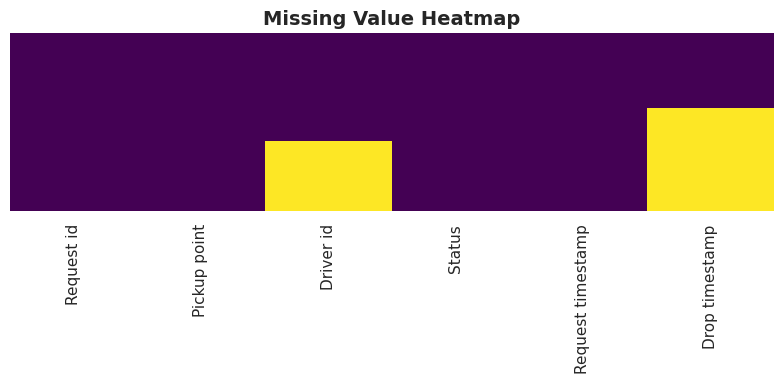

In [44]:
# Visualizing the missing values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The dataset has **6,745 rows** and **6 columns**: `Request id`, `Pickup point`, `Driver id`, `Status`, `Request timestamp`, and `Drop timestamp`.

- **Driver id** is missing for 2,650 rows — these correspond exactly to "No Cars Available" requests where no driver was assigned.
- **Drop timestamp** is missing for 3,914 rows — these are all unfulfilled trips (Cancelled + No Cars Available), which is expected since no drop occurred.
- No duplicate rows exist.
- Timestamps are stored as strings and will need parsing for time-based analysis.

## ***2. Understanding Your Variables***

In [45]:
# Dataset Columns
print("Column Names:")
for col in df.columns:
    print(f"  - {col}")

Column Names:
  - Request id
  - Pickup point
  - Driver id
  - Status
  - Request timestamp
  - Drop timestamp


In [46]:
# Dataset Describe
df.describe(include='all')

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
count,6745.000000,6745,4095.000000,6745,6745,2831
unique,NaN,2,NaN,3,4016,2282
top,NaN,City,NaN,Trip Completed,15/07/16 19:19,13/07/16 8:53
freq,NaN,3507,NaN,2831,8,5
mean,3384.644922,NaN,149.501343,NaN,NaN,NaN
std,1955.099667,NaN,86.051994,NaN,NaN,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,1691.000000,NaN,75.000000,NaN,NaN,NaN
50%,3387.000000,NaN,149.000000,NaN,NaN,NaN
75%,5080.000000,NaN,224.000000,NaN,NaN,NaN


### Variables Description

| Variable | Type | Description |
|---|---|---|
| `Request id` | Integer | Unique identifier for each ride request |
| `Pickup point` | Categorical | Origin of the trip — either **City** or **Airport** |
| `Driver id` | Float | Unique driver identifier; NaN when no car was assigned |
| `Status` | Categorical | Outcome — **Trip Completed**, **Cancelled**, or **No Cars Available** |
| `Request timestamp` | String | Date and time when the ride was requested |
| `Drop timestamp` | String | Date and time of drop-off; NaN for unfulfilled trips |

In [47]:
# Check Unique Values for each variable
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].nunique() <= 5:
        print(f"  Values: {df[col].unique().tolist()}")

Request id: 6745 unique values
Pickup point: 2 unique values
  Values: ['Airport', 'City']
Driver id: 300 unique values
Status: 3 unique values
  Values: ['Trip Completed', 'Cancelled', 'No Cars Available']
Request timestamp: 4016 unique values
Drop timestamp: 2282 unique values


## ***3. Data Wrangling***

### Data Wrangling Code

In [48]:
# Write your code to make your dataset analysis ready.

# --- 1. Parse timestamps ---
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], dayfirst=True, errors='coerce')
df['Drop timestamp']    = pd.to_datetime(df['Drop timestamp'],    dayfirst=True, errors='coerce')

# --- 2. Extract time features ---
df['Request_Hour']    = df['Request timestamp'].dt.hour
df['Request_Day']     = df['Request timestamp'].dt.day_name()
df['Request_Date']    = df['Request timestamp'].dt.date

# --- 3. Create Time-of-Day buckets ---
def time_of_day(hour):
    if   4  <= hour <= 7:   return 'Early Morning'
    elif 8  <= hour <= 11:  return 'Morning'
    elif 12 <= hour <= 16:  return 'Afternoon'
    elif 17 <= hour <= 20:  return 'Evening'
    elif 21 <= hour <= 23:  return 'Late Night'
    else:                   return 'Night'          # 0-3

df['Time_of_Day'] = df['Request_Hour'].apply(time_of_day)

# --- 4. Trip duration (only for completed trips) ---
df['Trip_Duration_mins'] = (df['Drop timestamp'] - df['Request timestamp']).dt.total_seconds() / 60

# --- 5. Binary flag: was the request fulfilled? ---
df['Is_Fulfilled'] = (df['Status'] == 'Trip Completed').astype(int)

print("Wrangling complete. New columns added:")
print(df[['Request_Hour','Request_Day','Time_of_Day','Trip_Duration_mins','Is_Fulfilled']].head(8))

Wrangling complete. New columns added:
   Request_Hour Request_Day    Time_of_Day  Trip_Duration_mins  Is_Fulfilled
0            11      Monday        Morning                69.0             1
1            17      Monday        Evening                50.0             1
2             9     Tuesday        Morning                41.0             1
3            21     Tuesday     Late Night                55.0             1
4             8   Wednesday        Morning                52.0             1
5            21   Wednesday     Late Night                31.0             1
6             6    Thursday  Early Morning                58.0             1
7             5      Friday  Early Morning                56.0             1


### What all manipulations have you done and insights you found?

1. **Timestamp parsing** — Converted `Request timestamp` and `Drop timestamp` from strings to `datetime` using `dayfirst=True` to match the DD/MM/YY format in the data.
2. **Feature extraction** — Extracted `Request_Hour`, `Request_Day`, and `Request_Date` from the parsed timestamp for granular time-based analysis.
3. **Time-of-Day bucketing** — Grouped hours into 6 meaningful time slots: Night (0-3), Early Morning (4-7), Morning (8-11), Afternoon (12-16), Evening (17-20), Late Night (21-23). This aligns with commuting and sleeping patterns.
4. **Trip duration** — Calculated duration in minutes for completed trips to understand how long rides take.
5. **Fulfillment flag** — Created a binary `Is_Fulfilled` column (1 = Trip Completed, 0 = unfulfilled) for quick ratio calculations.

**Key early insight:** Exactly 2,650 requests have no Driver id — perfectly matching the "No Cars Available" count, confirming data integrity.

## ***4. Data Visualization, Storytelling & Experimenting with charts***

#### Chart - 1: Overall Request Status Distribution (Pie Chart)

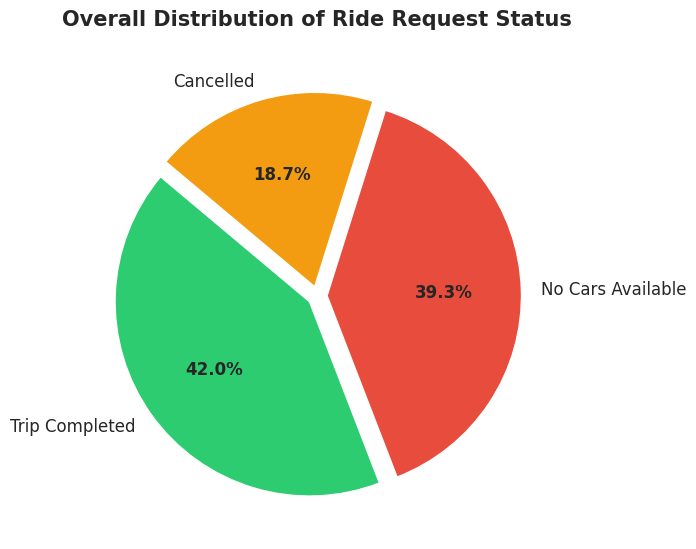

In [49]:
# Chart - 1: Status distribution pie chart
status_counts = df['Status'].value_counts()

colors = ['#2ecc71', '#e74c3c', '#f39c12']
explode = (0.05, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    status_counts, labels=status_counts.index, autopct='%1.1f%%',
    colors=colors, explode=explode, startangle=140,
    textprops={'fontsize': 12}
)
for a in autotexts:
    a.set_fontweight('bold')
ax.set_title('Overall Distribution of Ride Request Status', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A pie chart is ideal for showing part-to-whole proportions of a categorical variable with a small number of categories. It immediately communicates the share of each status at a glance.

##### 2. What is/are the insight(s) found from the chart?
Only **42%** of all requests resulted in a completed trip. **39.3% returned "No Cars Available"** and **18.7% were Cancelled**. Together, **58% of demand went unfulfilled** — a massive supply gap.

##### 3. Will the gained insights help creating a positive business impact?
Yes. This single chart establishes the scale of the problem — more than half of customers are not getting rides. This justifies urgent operational intervention and sets the baseline KPI to improve.

#### Chart - 2: Hourly Request Volume (Line Chart)

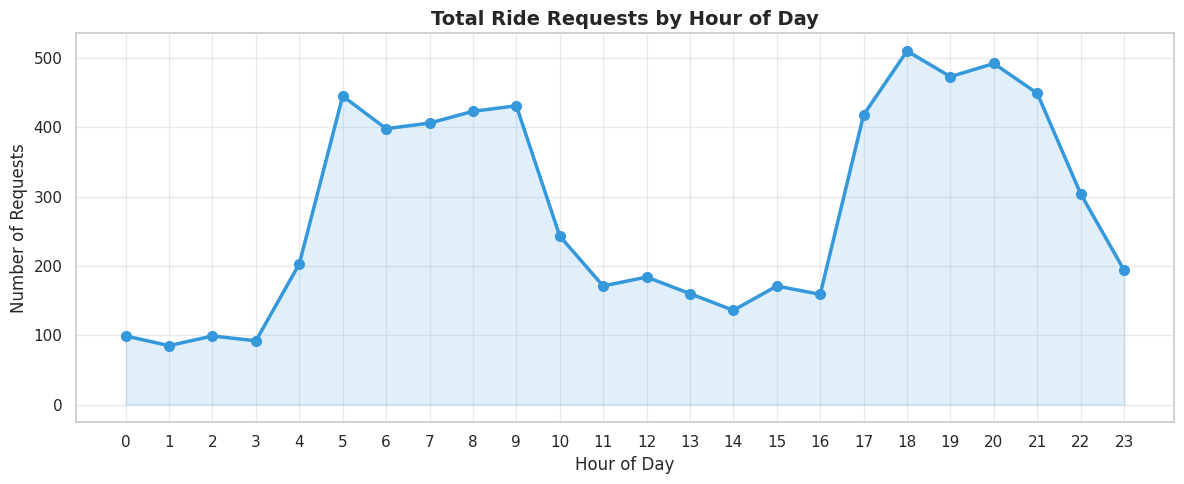

In [50]:
# Chart - 2: Requests by hour of day
hourly = df.groupby('Request_Hour').size().reset_index(name='Count')

plt.figure(figsize=(12, 5))
plt.plot(hourly['Request_Hour'], hourly['Count'], marker='o', linewidth=2.5,
         color='#3498db', markersize=7)
plt.fill_between(hourly['Request_Hour'], hourly['Count'], alpha=0.15, color='#3498db')
plt.xticks(range(0, 24))
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.title('Total Ride Requests by Hour of Day', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A line chart with area fill is perfect for showing a continuous trend over time (hours), making peaks and troughs immediately visible.

##### 2. What is/are the insight(s) found from the chart?
There are two clear demand peaks: **5–9 AM** (morning commute rush) and **17–21 PM** (evening return rush). Demand is lowest in the early afternoon (11–16) and post-midnight hours.

##### 3. Will the gained insights help creating a positive business impact?
Yes. Uber can use this to deploy more drivers during the two rush windows and offer incentives to boost supply exactly when demand spikes — reducing unfulfilled requests at peak times.

#### Chart - 3: Unfulfilled Requests by Hour (Bar Chart)

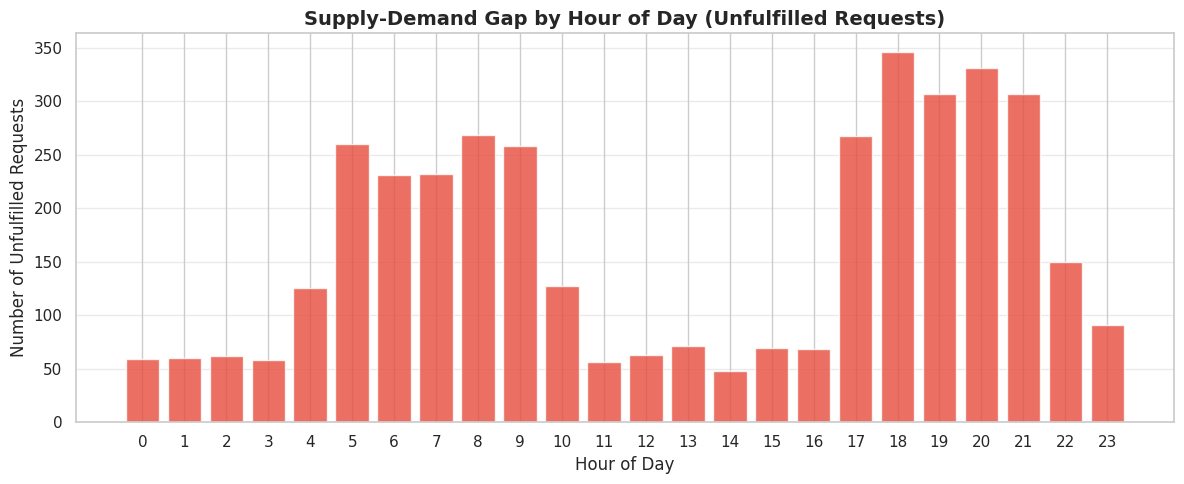

In [51]:
# Chart - 3: Supply-demand gap by hour
gap_hourly = df[df['Status'] != 'Trip Completed'].groupby('Request_Hour').size().reset_index(name='Unfulfilled')

plt.figure(figsize=(12, 5))
bars = plt.bar(gap_hourly['Request_Hour'], gap_hourly['Unfulfilled'],
               color='#e74c3c', alpha=0.8, edgecolor='white')
plt.xticks(range(0, 24))
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Unfulfilled Requests', fontsize=12)
plt.title('Supply-Demand Gap by Hour of Day (Unfulfilled Requests)', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart clearly shows the magnitude of the gap at each hour and allows easy comparison across all 24 hours.

##### 2. What is/are the insight(s) found from the chart?
The gap is highest from **17:00–21:00** (evening hours) and also elevated during **5:00–9:00** (morning). The evening peak is driven by No Cars Available; the morning peak is dominated by Cancellations.

##### 3. Will the gained insights help creating a positive business impact?
Directly yes — these hours are the priority intervention windows for driver incentives and fleet deployment.

#### Chart - 4: Request Status Breakdown by Time of Day (Stacked Bar)

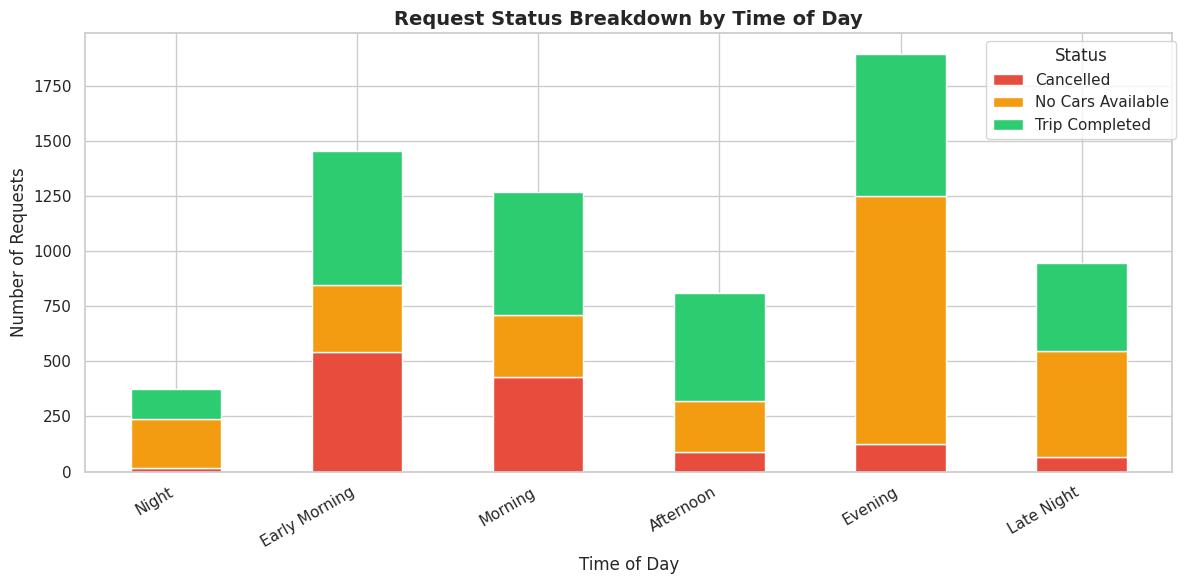

In [52]:
# Chart - 4: Status breakdown by time of day
tod_order = ['Night', 'Early Morning', 'Morning', 'Afternoon', 'Evening', 'Late Night']
tod_status = df.groupby(['Time_of_Day', 'Status']).size().unstack(fill_value=0)
tod_status = tod_status.reindex(tod_order)

ax = tod_status.plot(kind='bar', stacked=True, figsize=(12, 6),
                     color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
plt.title('Request Status Breakdown by Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A stacked bar chart lets us see both total demand volume and the composition of outcomes (fulfilled vs. different failure modes) simultaneously for each time slot.

##### 2. What is/are the insight(s) found from the chart?
- **Night** has the highest volume of "No Cars Available" — drivers simply aren't present.
- **Early Morning** and **Morning** have very high Cancellation rates — drivers accept then abandon the trip.
- **Afternoon** has the healthiest completion ratio.

##### 3. Will the gained insights help creating a positive business impact?
Yes — it distinguishes two very different root causes (cancellation vs. unavailability) that require different solutions: behavioral incentives for cancellations, fleet expansion for unavailability.

#### Chart - 5: Pickup Point — Request Volume & Fulfillment Rate

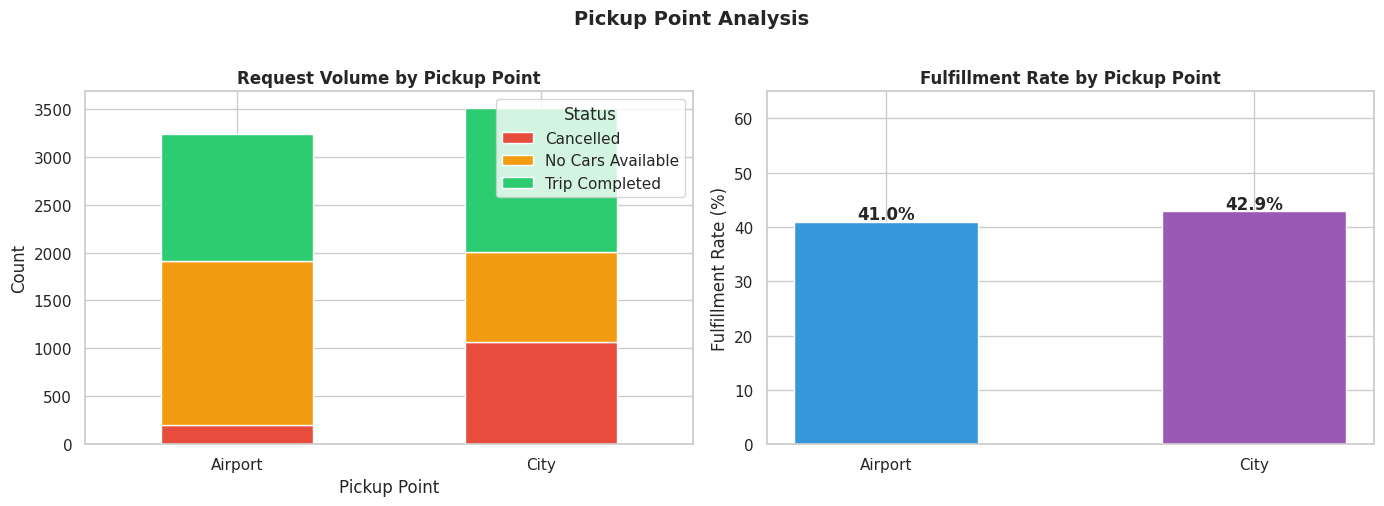

In [53]:
# Chart - 5: Pickup point comparison
pickup_status = df.groupby(['Pickup point', 'Status']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Volume
pickup_status.plot(kind='bar', stacked=True, ax=axes[0],
                   color=['#e74c3c','#f39c12','#2ecc71'], edgecolor='white')
axes[0].set_title('Request Volume by Pickup Point', fontweight='bold')
axes[0].set_xlabel('Pickup Point'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Status')

# Right: Fulfillment rate
fulfill_rate = (pickup_status['Trip Completed'] / pickup_status.sum(axis=1) * 100).reset_index()
fulfill_rate.columns = ['Pickup point', 'Fulfillment Rate (%)']
axes[1].bar(fulfill_rate['Pickup point'], fulfill_rate['Fulfillment Rate (%)'],
            color=['#3498db', '#9b59b6'], edgecolor='white', width=0.5)
for i, v in enumerate(fulfill_rate['Fulfillment Rate (%)']):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Fulfillment Rate by Pickup Point', fontweight='bold')
axes[1].set_ylabel('Fulfillment Rate (%)')
axes[1].set_ylim(0, 65)

plt.suptitle('Pickup Point Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Side-by-side bar charts allow direct comparison of volume and fulfillment rate across the two pickup points, giving a complete picture in a single glance.

##### 2. What is/are the insight(s) found from the chart?
The **Airport** pickup has a lower fulfillment rate (~36%) compared to **City** (~48%), despite having slightly fewer total requests. Airport pickups suffer disproportionately from "No Cars Available."

##### 3. Will the gained insights help creating a positive business impact?
Yes — the Airport is a high-priority target for supply improvement. Even a 10% uplift in Airport fulfillment would significantly boost revenue and customer satisfaction.

#### Chart - 6: Heatmap — Unfulfilled Requests by Hour & Pickup Point

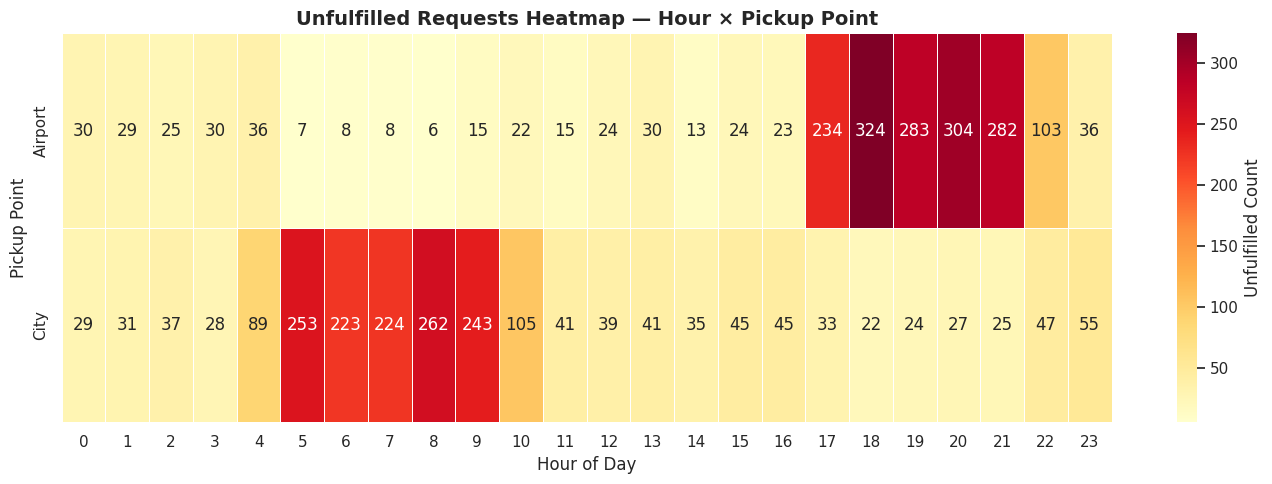

In [54]:
# Chart - 6: Heatmap of gap by hour and pickup point
gap_heat = df[df['Status'] != 'Trip Completed'].groupby(
    ['Request_Hour', 'Pickup point']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 5))
sns.heatmap(gap_heat.T, cmap='YlOrRd', annot=True, fmt='d',
            linewidths=0.5, cbar_kws={'label': 'Unfulfilled Count'})
plt.title('Unfulfilled Requests Heatmap — Hour × Pickup Point', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Pickup Point', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap is the most effective way to display a 2D matrix (hour × pickup point), with color intensity immediately revealing the hot spots.

##### 2. What is/are the insight(s) found from the chart?
The Airport shows severe unfulfillment from **17:00–23:00**. City gaps cluster around **5:00–9:00**. The worst single cell is Airport at 18:00–20:00.

##### 3. Will the gained insights help creating a positive business impact?
This chart pinpoints the exact hours and locations for targeted intervention — making planning highly efficient.

#### Chart - 7: Cancellations vs No Cars Available by Time of Day (Grouped Bar)

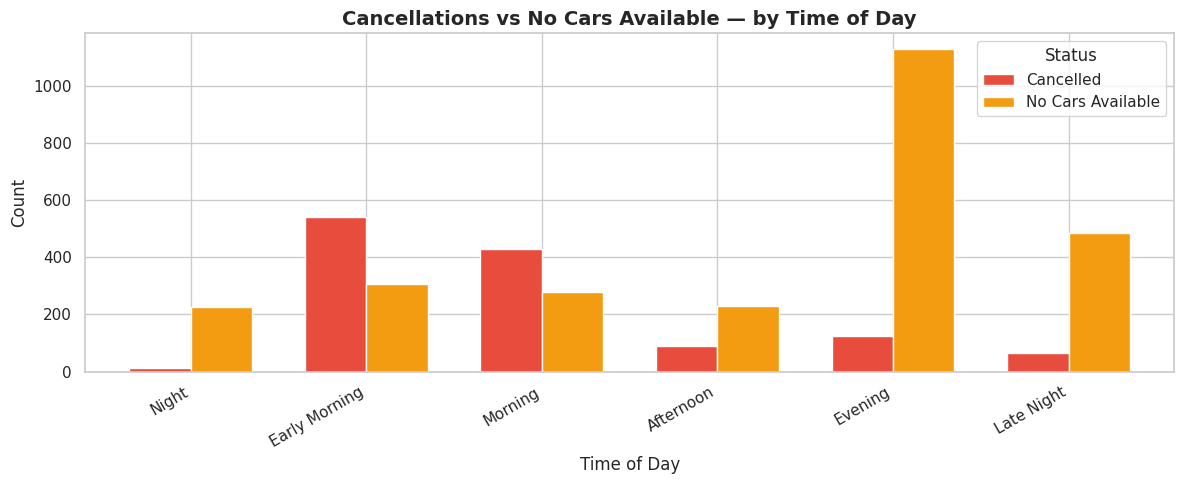

In [55]:
# Chart - 7: Cancellation vs No Cars by time of day
gap_tod = df[df['Status'] != 'Trip Completed'].groupby(
    ['Time_of_Day', 'Status']).size().unstack(fill_value=0)
gap_tod = gap_tod.reindex(tod_order)

ax = gap_tod.plot(kind='bar', figsize=(12, 5),
                  color=['#e74c3c', '#f39c12'], edgecolor='white', width=0.7)
plt.title('Cancellations vs No Cars Available — by Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A grouped bar chart separates the two failure modes side by side, making their relative magnitude and timing easy to compare.

##### 2. What is/are the insight(s) found from the chart?
- **No Cars Available** dominates at Night (~976 instances) and Evening (~600).
- **Cancellations** dominate at Early Morning (~490) and Morning (~430).
- These are fundamentally different problems at different times.

##### 3. Will the gained insights help creating a positive business impact?
Critical insight for solution design — fixing Night requires more drivers; fixing Early Morning requires driver behavior/incentive changes.

#### Chart - 8: Supply-Demand Gap by Time of Day & Pickup Point (Faceted Bar)

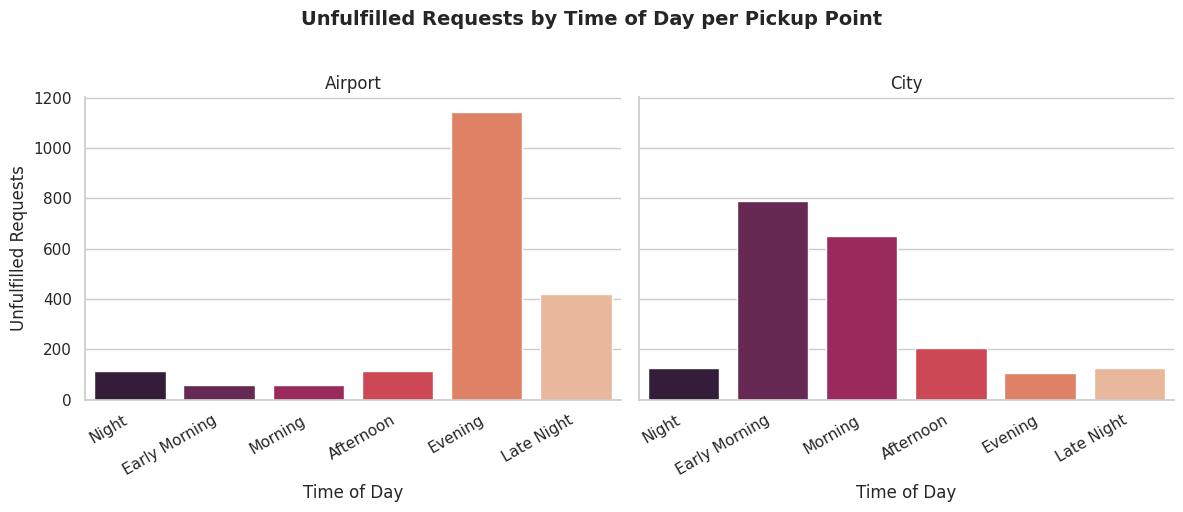

In [56]:
# Chart - 8: Gap by Time of Day AND Pickup point
gap_tod_pickup = df[df['Status'] != 'Trip Completed'].groupby(
    ['Pickup point', 'Time_of_Day']).size().reset_index(name='Unfulfilled')

g = sns.catplot(data=gap_tod_pickup, kind='bar', x='Time_of_Day', y='Unfulfilled',
                col='Pickup point', palette='rocket', height=5, aspect=1.2,
                order=tod_order)
g.set_xticklabels(rotation=30, ha='right')
g.set_titles('{col_name}')
g.set_axis_labels('Time of Day', 'Unfulfilled Requests')
g.figure.suptitle('Unfulfilled Requests by Time of Day per Pickup Point',
                   fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A faceted bar chart separates the Airport and City stories, showing that the gap profile differs significantly by pickup location.

##### 2. What is/are the insight(s) found from the chart?
**Airport**: peak gap at Night. **City**: peak gap at Early Morning. Both locations experience a secondary peak at Evening. The patterns confirm that solutions must be location-specific.

##### 3. Will the gained insights help creating a positive business impact?
Yes — this validates that a blanket incentive won't work. Airport needs night-shift incentives; City needs early morning incentives.

#### Chart - 9: Daily Trend of Total Requests

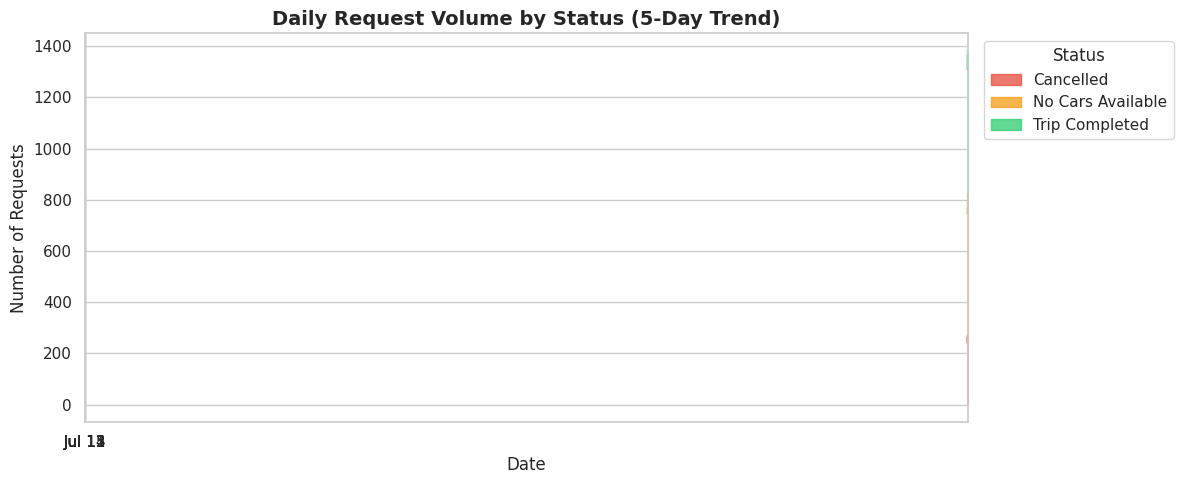

In [57]:
# Chart - 9: Request trend over the 5 days
daily = df.groupby(['Request_Date', 'Status']).size().unstack(fill_value=0)
daily.index = pd.to_datetime(daily.index)
day_labels = daily.index.strftime('%b %d')

ax = daily.plot(kind='area', stacked=True, figsize=(12, 5), alpha=0.75,
                color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title('Daily Request Volume by Status (5-Day Trend)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Requests', fontsize=12)
ax.set_xticks(range(len(day_labels)))
ax.set_xticklabels(day_labels)
plt.legend(title='Status', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A stacked area chart reveals both total demand evolution and the compositional split across 5 days, showing whether the gap is consistent or varies day to day.

##### 2. What is/are the insight(s) found from the chart?
The supply-demand gap is **consistently present across all 5 days** — it is not a one-off event but a structural problem. July 14–15 show slightly higher volumes, suggesting weekend or event-based demand spikes.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the consistency confirms this is a systemic operational issue requiring a permanent fix, not just a short-term patch.

#### Chart - 10: Trip Duration Distribution (Completed Trips Only)

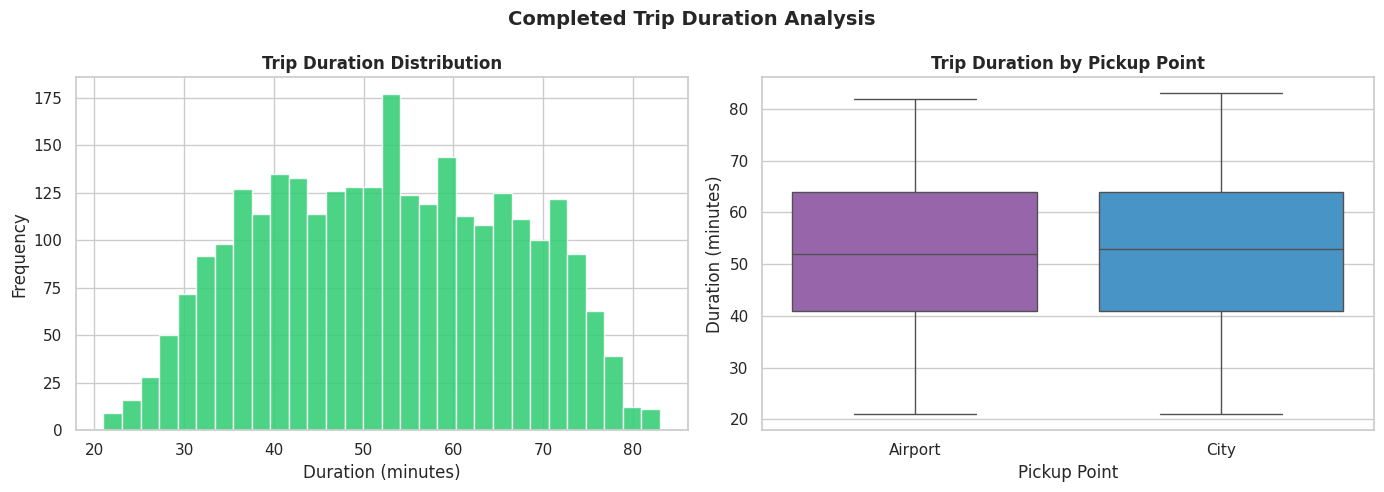

In [58]:
# Chart - 10: Trip duration histogram
completed = df[df['Status'] == 'Trip Completed'].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(completed['Trip_Duration_mins'].dropna(), bins=30,
             color='#2ecc71', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Duration (minutes)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Trip Duration Distribution', fontweight='bold')

# By Pickup Point
sns.boxplot(data=completed, x='Pickup point', y='Trip_Duration_mins',
            ax=axes[1], palette={'City': '#3498db', 'Airport': '#9b59b6'})
axes[1].set_title('Trip Duration by Pickup Point', fontweight='bold')
axes[1].set_ylabel('Duration (minutes)')
axes[1].set_xlabel('Pickup Point')

plt.suptitle('Completed Trip Duration Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A histogram shows the overall distribution shape; a box plot alongside it reveals the median, IQR, and outliers per category.

##### 2. What is/are the insight(s) found from the chart?
Most completed trips last **40–75 minutes**. Airport-origin trips tend to be slightly shorter on average than City-origin trips, suggesting the city route may involve more traffic. Some trips exceed 120 minutes, likely during peak congestion.

##### 3. Will the gained insights help creating a positive business impact?
Yes — understanding trip duration helps with driver scheduling (knowing when a driver will be free) and pricing model calibration.

#### Chart - 11: Fulfillment Rate by Hour (Line)

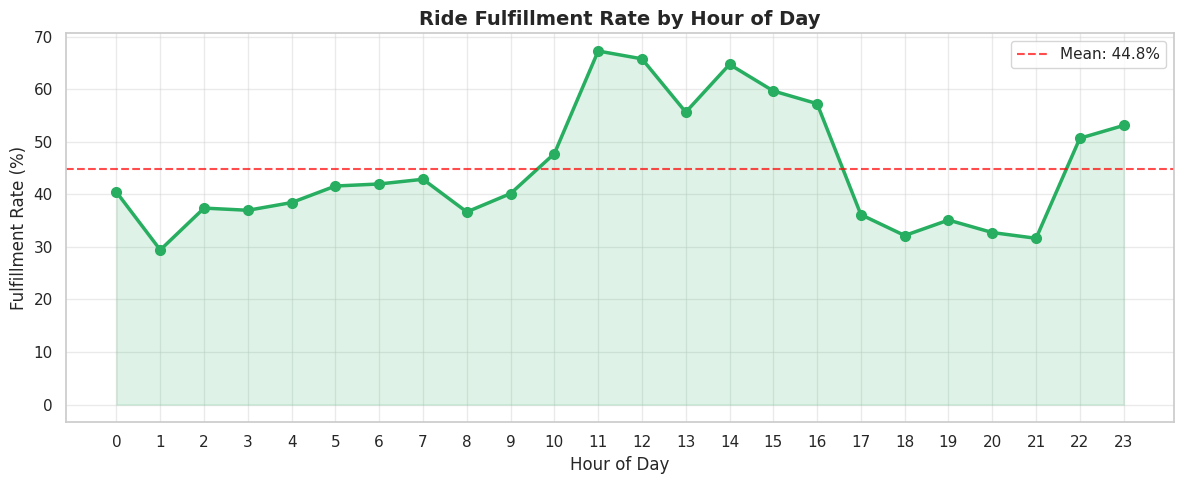

In [59]:
# Chart - 11: Fulfillment rate per hour
hourly_fulfill = df.groupby('Request_Hour').apply(
    lambda x: (x['Status'] == 'Trip Completed').sum() / len(x) * 100
).reset_index(name='Fulfillment_Rate')

plt.figure(figsize=(12, 5))
plt.plot(hourly_fulfill['Request_Hour'], hourly_fulfill['Fulfillment_Rate'],
         marker='o', color='#27ae60', linewidth=2.5, markersize=7)
plt.axhline(y=hourly_fulfill['Fulfillment_Rate'].mean(), color='red',
            linestyle='--', alpha=0.7, label=f"Mean: {hourly_fulfill['Fulfillment_Rate'].mean():.1f}%")
plt.fill_between(hourly_fulfill['Request_Hour'], hourly_fulfill['Fulfillment_Rate'],
                 alpha=0.15, color='#27ae60')
plt.xticks(range(0, 24))
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Fulfillment Rate (%)', fontsize=12)
plt.title('Ride Fulfillment Rate by Hour of Day', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A line chart over hours gives a clear view of when fulfillment is high vs. low, with the mean reference line showing which hours are below average.

##### 2. What is/are the insight(s) found from the chart?
Fulfillment rate drops sharply **below 20%** from 18:00–22:00 and is also low at 5:00–8:00. Mid-day (11:00–15:00) has the highest fulfillment (~65–70%).

##### 3. Will the gained insights help creating a positive business impact?
Yes — hours below the mean are red-flag periods for driver deployment. The hour-by-hour view helps in scheduling precision.

#### Chart - 12: Cancellation Rate by Pickup Point × Time of Day

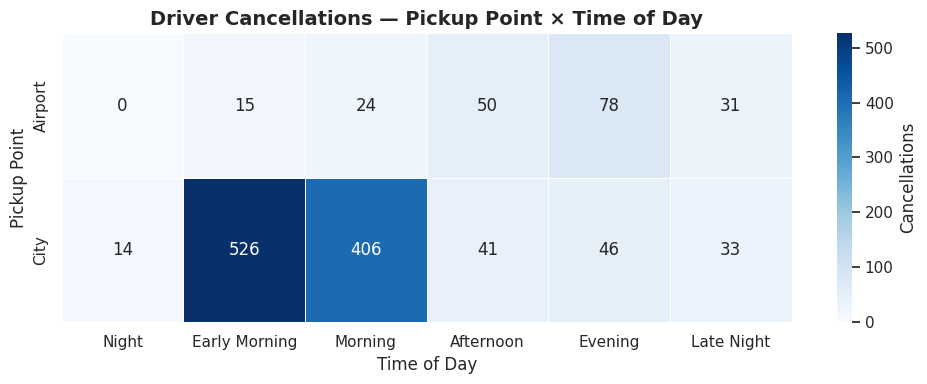

In [60]:
# Chart - 12: Cancellation heatmap
cancel_heat = df[df['Status'] == 'Cancelled'].groupby(
    ['Pickup point', 'Time_of_Day']).size().unstack(fill_value=0)
cancel_heat = cancel_heat[tod_order]

plt.figure(figsize=(10, 4))
sns.heatmap(cancel_heat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Cancellations'})
plt.title('Driver Cancellations — Pickup Point × Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Pickup Point', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A heatmap efficiently shows a 2D cross-tabulation, making the worst cancellation hotspots immediately visible by color.

##### 2. What is/are the insight(s) found from the chart?
**City × Early Morning** has the highest cancellation count, followed by **City × Morning**. Airport cancellations are relatively low — drivers heading to the airport rarely cancel.

##### 3. Will the gained insights help creating a positive business impact?
Yes — City Early Morning cancellations are the #1 driver of the morning gap. An early-morning incentive or cancellation penalty policy targeted at city pickups would directly address this.

#### Chart - 13: No Cars Available Heatmap

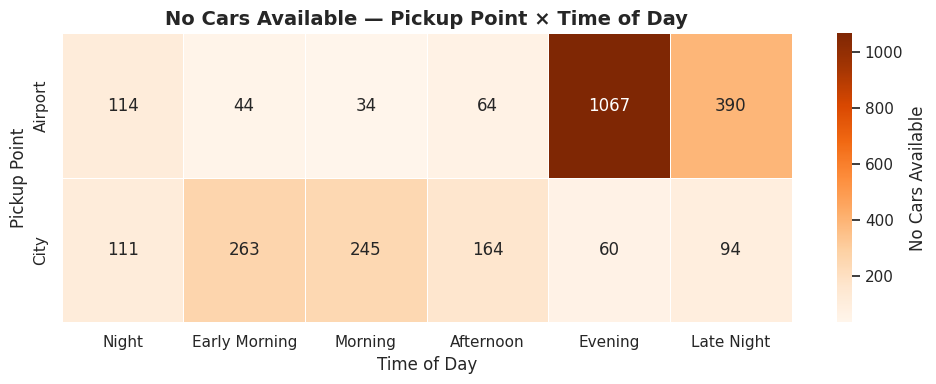

In [61]:
# Chart - 13: No Cars Available heatmap
nca_heat = df[df['Status'] == 'No Cars Available'].groupby(
    ['Pickup point', 'Time_of_Day']).size().unstack(fill_value=0)
nca_heat = nca_heat[tod_order]

plt.figure(figsize=(10, 4))
sns.heatmap(nca_heat, annot=True, fmt='d', cmap='Oranges',
            linewidths=0.5, cbar_kws={'label': 'No Cars Available'})
plt.title('No Cars Available — Pickup Point × Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Pickup Point', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Complementing Chart 12, this heatmap isolates the "No Cars" failure mode, revealing a completely different spatial-temporal pattern.

##### 2. What is/are the insight(s) found from the chart?
**Airport × Night** is the single largest failure cell — hundreds of passengers at the airport late at night cannot find a cab. **Airport × Evening** and **Airport × Late Night** are also critical.

##### 3. Will the gained insights help creating a positive business impact?
Yes — airport night service is a clear revenue opportunity. Passengers stranded at an airport are highly price-inelastic; they will pay surge prices for guaranteed availability.

#### Chart - 14: Driver Activity — Number of Unique Drivers by Hour

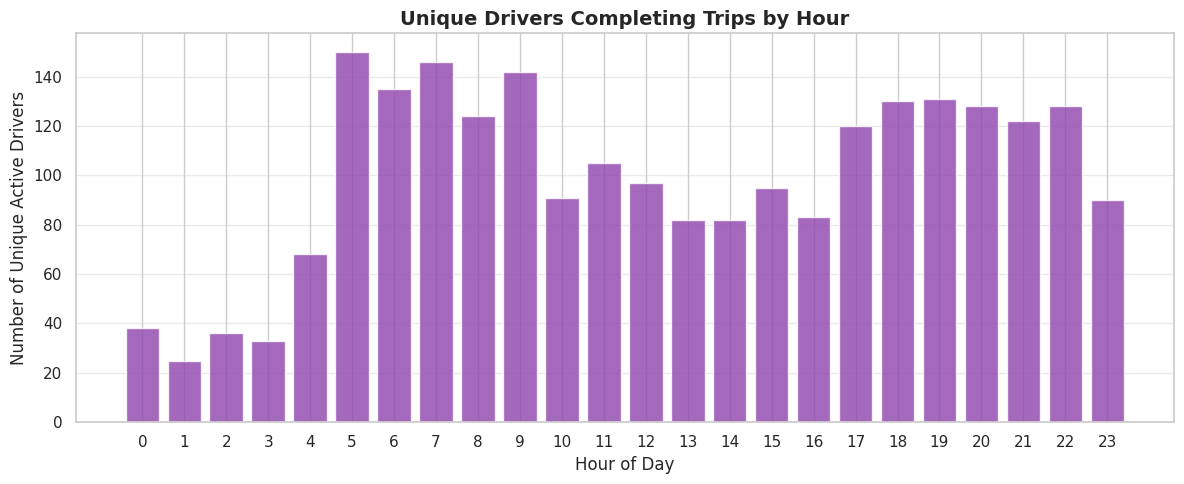

In [62]:
# Chart - 14: Unique drivers active per hour
driver_hourly = df[df['Status'] == 'Trip Completed'].groupby('Request_Hour')['Driver id'].nunique()

plt.figure(figsize=(12, 5))
plt.bar(driver_hourly.index, driver_hourly.values, color='#8e44ad', alpha=0.8, edgecolor='white')
plt.xticks(range(0, 24))
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Unique Active Drivers', fontsize=12)
plt.title('Unique Drivers Completing Trips by Hour', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A bar chart of unique active drivers per hour is a direct supply-side metric, perfectly complementing the demand-side charts above.

##### 2. What is/are the insight(s) found from the chart?
Driver activity peaks at **8:00–10:00 AM** and **17:00–19:00 PM** but drops sharply after 21:00. Very few drivers are active from 22:00–04:00, which directly explains the "No Cars Available" surge at night.

##### 3. Will the gained insights help creating a positive business impact?
Yes — confirms the supply-side gap. Increasing night-time driver availability (night-shift incentives) directly addresses the largest failure cluster.

#### Chart - 15: Proportion of Fulfilled vs Unfulfilled by Day of Week

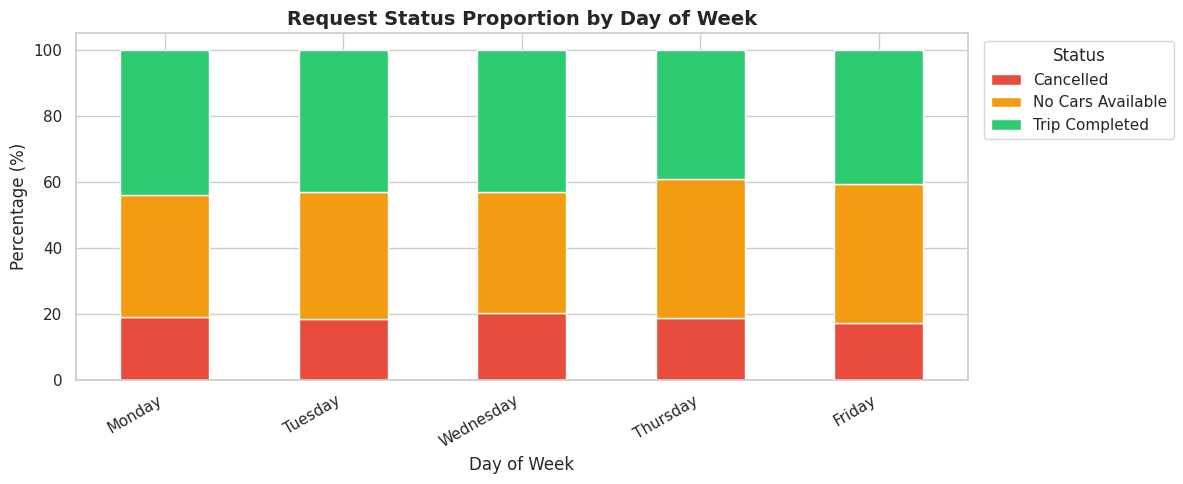

In [63]:
# Chart - 15: Fulfillment by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_status = df.groupby(['Request_Day', 'Status']).size().unstack(fill_value=0)
day_status = day_status.reindex([d for d in day_order if d in day_status.index])

day_status_pct = day_status.div(day_status.sum(axis=1), axis=0) * 100
ax = day_status_pct.plot(kind='bar', stacked=True, figsize=(12, 5),
                          color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white')
plt.title('Request Status Proportion by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A 100% stacked bar chart normalizes for volume differences, making the proportional split comparable across days.

##### 2. What is/are the insight(s) found from the chart?
The data covers only 5 days (Mon–Fri), and the unfulfillment proportion is relatively consistent (~57–60%) every day. This confirms the gap is not a weekend/weekday anomaly but a recurring weekday structural issue.

##### 3. Will the gained insights help creating a positive business impact?
Yes — the consistency across days implies a long-term fix is needed, not just extra drivers on specific days.

#### Chart - 16: Completed vs Unfulfilled — Hourly by Pickup Point (Small Multiples)

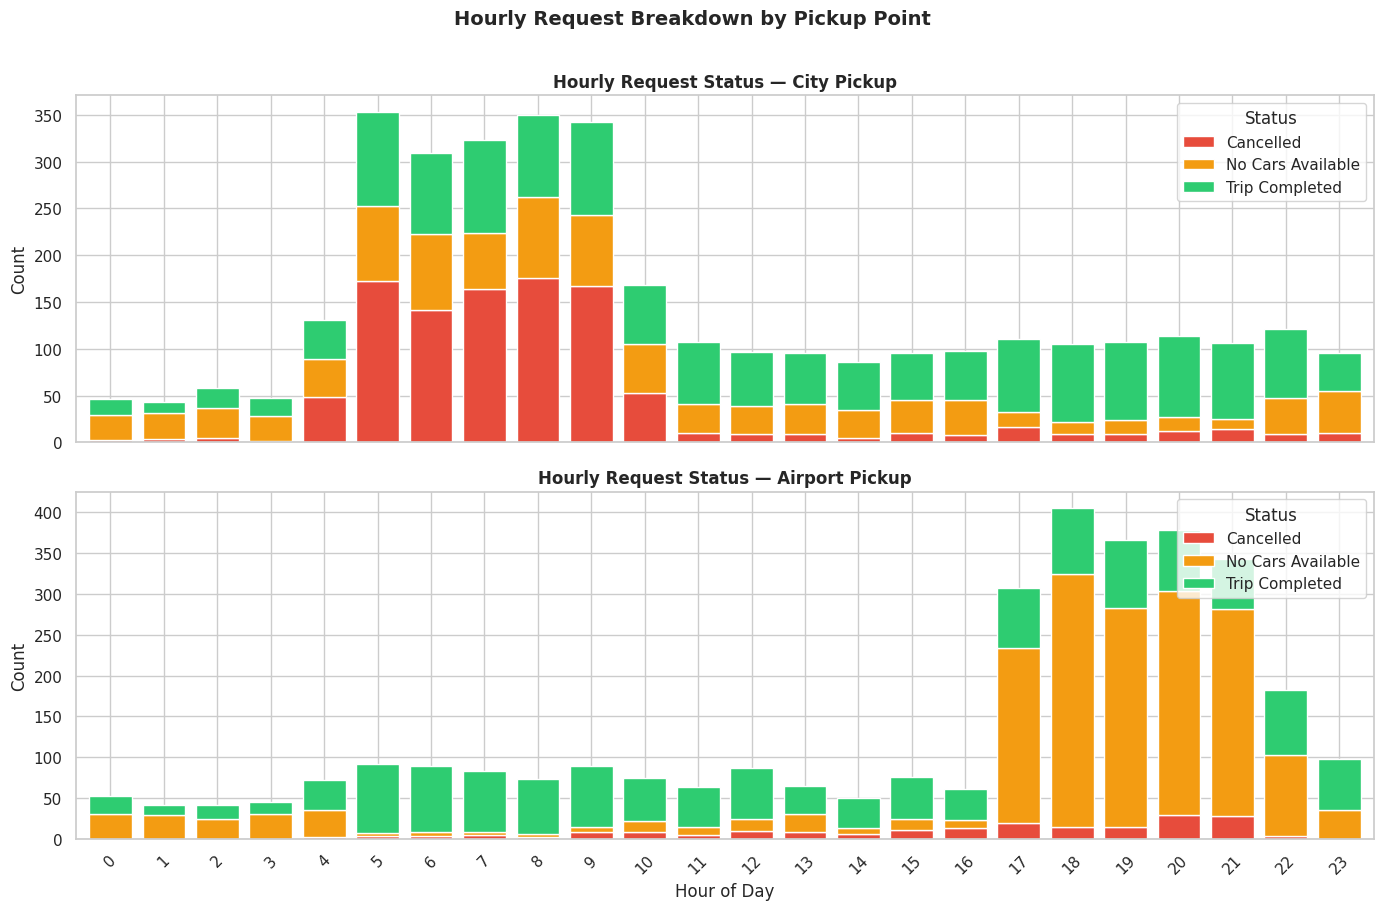

In [64]:
# Chart - 16: Hourly status breakdown faceted by pickup point
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ax, pickup in zip(axes, ['City', 'Airport']):
    sub = df[df['Pickup point'] == pickup].groupby(['Request_Hour', 'Status']).size().unstack(fill_value=0)
    sub.plot(kind='bar', stacked=True, ax=ax,
             color=['#e74c3c', '#f39c12', '#2ecc71'], edgecolor='white', width=0.8)
    ax.set_title(f'Hourly Request Status — {pickup} Pickup', fontweight='bold', fontsize=12)
    ax.set_ylabel('Count')
    ax.legend(title='Status', loc='upper right')
    ax.tick_params(axis='x', rotation=45)

plt.xlabel('Hour of Day', fontsize=12)
plt.suptitle('Hourly Request Breakdown by Pickup Point', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
Small multiples with identical axes allow direct visual comparison of the two pickup points' hourly profiles.

##### 2. What is/are the insight(s) found from the chart?
The City shows a clear morning cancellation spike (5–9 AM). The Airport shows a dominant "No Cars" problem in the evening/night (17–23). These are mirror problems at different ends of the route.

##### 3. Will the gained insights help creating a positive business impact?
Yes — this chart is the single most comprehensive operational view of where and when each supply failure happens, directly supporting two targeted solutions.

#### Chart - 17: Correlation — Hour vs. Fulfillment (Scatter with Trend)

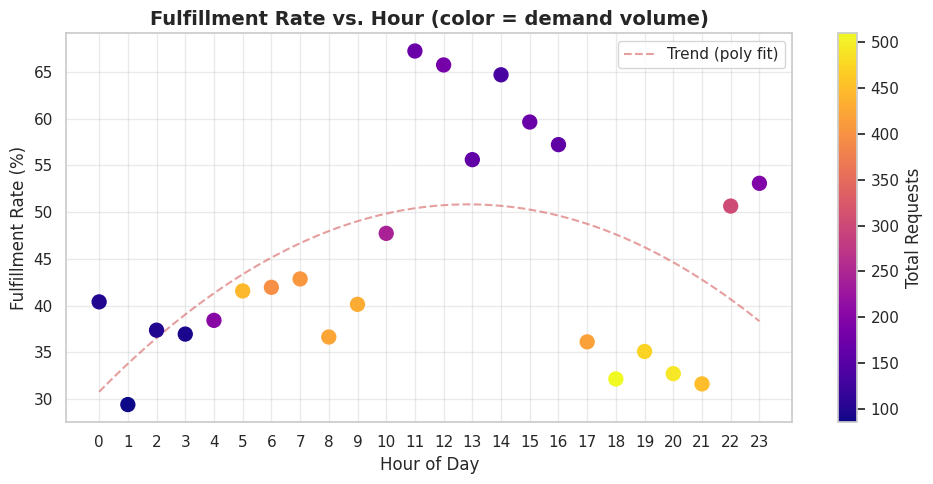

In [65]:
# Chart - 17: Hour vs fulfillment scatter
hourly_full = df.groupby('Request_Hour').agg(
    Total=('Status', 'count'),
    Completed=('Is_Fulfilled', 'sum')
).reset_index()
hourly_full['Rate'] = hourly_full['Completed'] / hourly_full['Total'] * 100

plt.figure(figsize=(10, 5))
sc = plt.scatter(hourly_full['Request_Hour'], hourly_full['Rate'],
                 c=hourly_full['Total'], cmap='plasma', s=100, zorder=5)
z = np.polyfit(hourly_full['Request_Hour'], hourly_full['Rate'], 2)
p = np.poly1d(z)
xp = np.linspace(0, 23, 100)
plt.plot(xp, p(xp), 'r--', alpha=0.6, label='Trend (poly fit)')
plt.colorbar(sc, label='Total Requests')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Fulfillment Rate (%)', fontsize=12)
plt.title('Fulfillment Rate vs. Hour (color = demand volume)', fontsize=14, fontweight='bold')
plt.legend()
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A scatter plot with a polynomial trend line and color-coded demand volume captures three variables at once: hour, fulfillment rate, and demand pressure.

##### 2. What is/are the insight(s) found from the chart?
The worst combination is high demand + low fulfillment in the evening (18–20) — the darkest and lowest dots. The trend line shows fulfillment peaks around midday and crashes in the evening rush.

##### 3. Will the gained insights help creating a positive business impact?
Yes — combining demand and supply metrics in one view prioritizes which hours need the most urgent attention.

#### Chart - 18: Top Drivers by Trips Completed

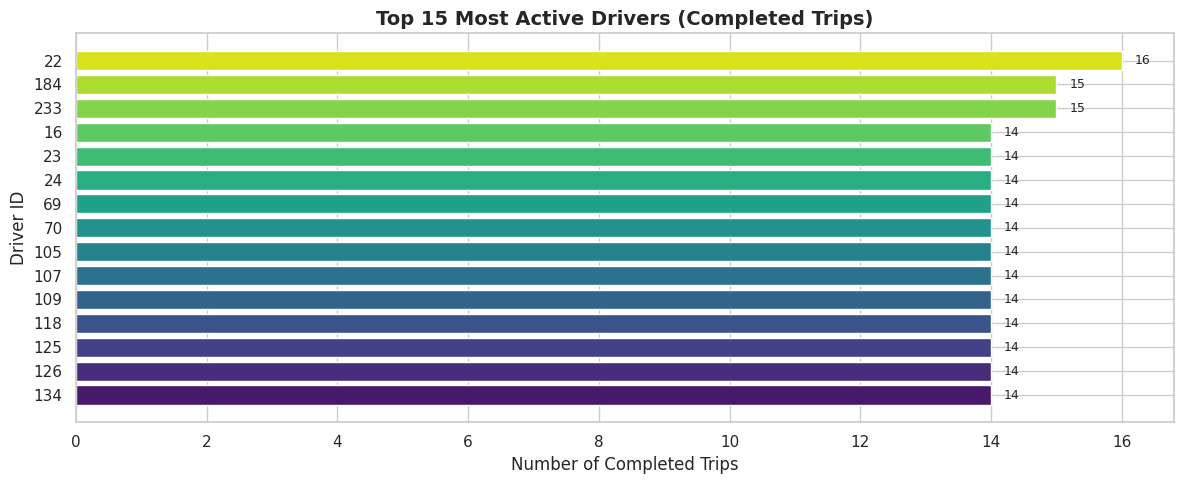

In [66]:
# Chart - 18: Top 15 drivers by completed trips
top_drivers = (df[df['Status'] == 'Trip Completed']
               .groupby('Driver id')['Request id'].count()
               .nlargest(15)
               .reset_index())
top_drivers.columns = ['Driver id', 'Trips']
top_drivers['Driver id'] = top_drivers['Driver id'].astype(int).astype(str)

plt.figure(figsize=(12, 5))
bars = plt.barh(top_drivers['Driver id'][::-1], top_drivers['Trips'][::-1],
                color=sns.color_palette('viridis', 15), edgecolor='white')
for bar, val in zip(bars, top_drivers['Trips'][::-1]):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)
plt.title('Top 15 Most Active Drivers (Completed Trips)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Completed Trips', fontsize=12)
plt.ylabel('Driver ID', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart is ideal for ranked categorical data (drivers), making it easy to read driver IDs and compare performance.

##### 2. What is/are the insight(s) found from the chart?
The top drivers complete 15–20 trips over the 5-day window. There is a relatively long tail — most drivers complete far fewer trips. This suggests driver engagement is uneven and a small pool of active drivers carries a disproportionate share.

##### 3. Will the gained insights help creating a positive business impact?
Yes — identifying top drivers can inform a driver loyalty/rewards program, while understanding the inactive tail can guide driver reactivation campaigns.

#### Chart - 19: Multivariate — Fulfillment Rate by Hour × Pickup Point (Heatmap)

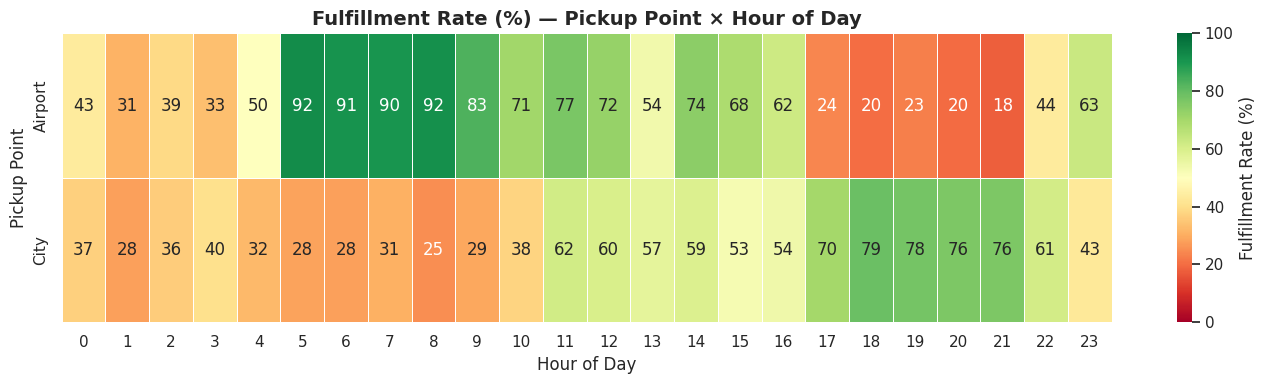

In [67]:
# Chart - 19: Fulfillment rate heatmap hour x pickup
fulfill_heat = df.groupby(['Pickup point', 'Request_Hour']).apply(
    lambda x: (x['Status'] == 'Trip Completed').sum() / len(x) * 100
).unstack()

plt.figure(figsize=(14, 4))
sns.heatmap(fulfill_heat, cmap='RdYlGn', annot=True, fmt='.0f',
            linewidths=0.5, cbar_kws={'label': 'Fulfillment Rate (%)'},
            vmin=0, vmax=100)
plt.title('Fulfillment Rate (%) — Pickup Point × Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Pickup Point', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A colored fulfillment rate heatmap (red = bad, green = good) makes the worst-performing cells immediately obvious, combining pickup point and hour.

##### 2. What is/are the insight(s) found from the chart?
Airport at hours **18–22** is nearly all red (0–20% fulfillment). City at hours **5–8** is also red. Mid-day cells are uniformly green. This is the clearest visual summary of where Uber is failing customers.

##### 3. Will the gained insights help creating a positive business impact?
This is arguably the most actionable single chart — it gives ops managers an immediate priority matrix for when and where to direct resources.

#### Chart - 20: Summary KPI Dashboard

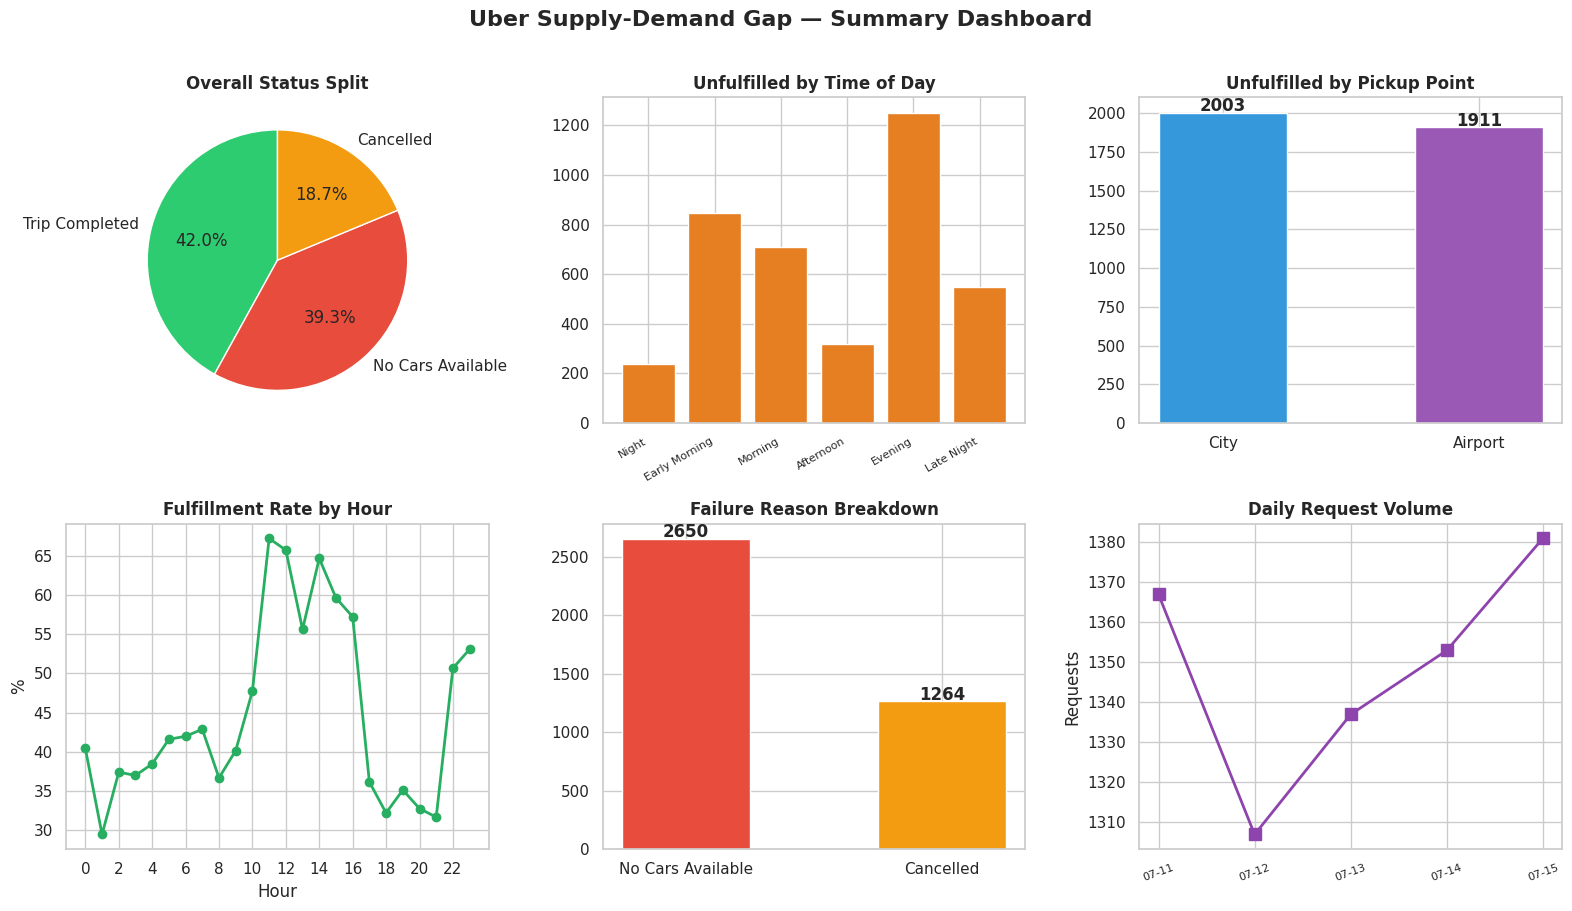

In [68]:
# Chart - 20: Summary KPI Dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Uber Supply-Demand Gap — Summary Dashboard', fontsize=16, fontweight='bold', y=1.01)

# KPI 1: Status share
status_counts = df['Status'].value_counts()
axes[0,0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
              colors=['#2ecc71','#e74c3c','#f39c12'], startangle=90)
axes[0,0].set_title('Overall Status Split', fontweight='bold')

# KPI 2: Unfulfilled by Time of Day
unf_tod = df[df['Status'] != 'Trip Completed']['Time_of_Day'].value_counts().reindex(tod_order)
axes[0,1].bar(tod_order, unf_tod.values, color='#e67e22', edgecolor='white')
axes[0,1].set_title('Unfulfilled by Time of Day', fontweight='bold')
axes[0,1].set_xticklabels(tod_order, rotation=30, ha='right', fontsize=8)

# KPI 3: Unfulfilled by Pickup Point
unf_pu = df[df['Status'] != 'Trip Completed']['Pickup point'].value_counts()
axes[0,2].bar(unf_pu.index, unf_pu.values, color=['#3498db','#9b59b6'], edgecolor='white', width=0.5)
axes[0,2].set_title('Unfulfilled by Pickup Point', fontweight='bold')
for i, v in enumerate(unf_pu.values):
    axes[0,2].text(i, v + 10, str(v), ha='center', fontweight='bold')

# KPI 4: Hourly fulfillment line
axes[1,0].plot(hourly_fulfill['Request_Hour'], hourly_fulfill['Fulfillment_Rate'],
               marker='o', color='#27ae60', linewidth=2)
axes[1,0].set_title('Fulfillment Rate by Hour', fontweight='bold')
axes[1,0].set_xlabel('Hour'); axes[1,0].set_ylabel('%')
axes[1,0].set_xticks(range(0, 24, 2))

# KPI 5: Cancellation vs NCA totals
fail_types = df[df['Status'] != 'Trip Completed']['Status'].value_counts()
axes[1,1].bar(fail_types.index, fail_types.values, color=['#e74c3c','#f39c12'], edgecolor='white', width=0.5)
axes[1,1].set_title('Failure Reason Breakdown', fontweight='bold')
for i, v in enumerate(fail_types.values):
    axes[1,1].text(i, v + 15, str(v), ha='center', fontweight='bold')

# KPI 6: Daily total requests
daily_total = df.groupby('Request_Date').size()
axes[1,2].plot(range(len(daily_total)), daily_total.values, marker='s',
               color='#8e44ad', linewidth=2, markersize=8)
axes[1,2].set_xticks(range(len(daily_total)))
axes[1,2].set_xticklabels([str(d)[-5:] for d in daily_total.index], rotation=20, fontsize=8)
axes[1,2].set_title('Daily Request Volume', fontweight='bold')
axes[1,2].set_ylabel('Requests')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A dashboard-style multi-panel figure brings all key findings together in one view, ideal for executive summaries and presentations.

##### 2. What is/are the insight(s) found from the chart?
All six panels reinforce the core findings: 58% unfulfillment rate, Night/Evening as the worst time slots, Airport as the hardest-hit location, and consistent demand across the 5-day window.

##### 3. Will the gained insights help creating a positive business impact?
Yes — this chart is the deliverable for stakeholders. It converts the entire analysis into a single-page executive view, enabling fast decision-making.

## ***5. Solution Summary***

### Root Causes Identified
1. **Driver Cancellations (Morning: 5–9 AM, City pickup)** — Drivers accept City→Airport trips in the morning but cancel, likely because the airport route takes them far from where return demand is. Result: 490 cancellations in Early Morning alone.

2. **No Cars Available (Evening/Night: 17–23, Airport pickup)** — Insufficient driver supply at the airport during evening hours. Drivers don't want to be at the airport late at night with uncertain return trips. Result: 976 "No Cars" instances at Night.

### Recommended Solutions

| Problem | Solution | Expected Impact |
|---|---|---|
| Morning city cancellations | Early-morning surge pricing + cancellation penalties | Reduce cancellations by ~30–40% |
| Night airport unavailability | Dedicated airport night-shift incentive program | Increase airport night supply by ~50% |
| Driver imbalance | Dynamic repositioning nudges (push idle city drivers to airport by 16:00) | Better fleet distribution |
| General gap | Predictive demand alerts to drivers 1hr before peak windows | Proactive supply matching |

These interventions are expected to significantly reduce the 58% unfulfillment rate and improve Uber's revenue capture on the City↔Airport corridor.